# **PROJECT DATA WAREHOUSE**
Analisis Kinerja Layanan Transportasi Udara Menggunakan Data Warehouse pada Data Keterlambatan dan Pembatalan Penerbangan Tahun 2019–2023

Kelompok 5 – S1 Sains Data, Universitas Negeri Surabaya

- Jeika Antama Syalom Tarigan (24031554011)
- Ayda' Nur Salzabillah (24031554017)
- Alifiyanti Putri Nur Azizah (24031554032)
- Grace Pinkkan Ladyna (24031554137)
Kelas 2024B

Dataset:https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023?select=flights_sample_3m.csv

# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (12, 5)

STAGING_DIR = 'Pembagian Batch'
os.makedirs(STAGING_DIR, exist_ok=True)

print('Library berhasil diimport')
print(f'Staging folder: {os.path.abspath(STAGING_DIR)}')

Library berhasil diimport
Staging folder: h:\SEMESTER 4\DataWarehouse\Projek Datwar\Pembagian Batch


# **Load Dataset**

In [2]:
dataset = "flights_sample_3m.csv"

df = pd.read_csv(
    dataset,
    low_memory=False
)

print(f"Jumlah Baris : {len(df):,}")
print(f"Jumlah Kolom : {len(df.columns)}")

Jumlah Baris : 3,000,000
Jumlah Kolom : 32


# **Data Understanding**

## 1. Struktur Dataset

Menampilkan informasi umum dataset seperti tipe data, jumlah record, dan jumlah atribut.

In [3]:
print('INFO DATASET')
df.info()

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  str    
 1   AIRLINE                  str    
 2   AIRLINE_DOT              str    
 3   AIRLINE_CODE             str    
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   str    
 7   ORIGIN_CITY              str    
 8   DEST                     str    
 9   DEST_CITY                str    
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCEL

In [4]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


## 2. Deskripsi Kolom

In [5]:
column_descriptions = {
    'FL_DATE'           : 'Tanggal penerbangan',
    'AIRLINE'           : 'Nama maskapai penerbangan',
    'AIRLINE_DOT'       : 'Kode maskapai (DOT)',
    'AIRLINE_CODE'      : 'Kode IATA maskapai',
    'DOT_CODE'          : 'Kode numerik DOT',
    'FL_NUMBER'         : 'Nomor penerbangan',
    'ORIGIN'            : 'Kode bandara asal (IATA)',
    'ORIGIN_CITY'       : 'Kota asal',
    'DEST'              : 'Kode bandara tujuan (IATA)',
    'DEST_CITY'         : 'Kota tujuan',
    'CRS_DEP_TIME'      : 'Jadwal keberangkatan (HHMM)',
    'DEP_TIME'          : 'Waktu keberangkatan aktual (HHMM)',
    'DEP_DELAY'         : 'Keterlambatan keberangkatan (menit)',
    'TAXI_OUT'          : 'Waktu taxi-out (menit)',
    'WHEELS_OFF'        : 'Waktu roda terangkat',
    'WHEELS_ON'         : 'Waktu roda mendarat',
    'TAXI_IN'           : 'Waktu taxi-in (menit)',
    'CRS_ARR_TIME'      : 'Jadwal kedatangan (HHMM)',
    'ARR_TIME'          : 'Waktu kedatangan aktual (HHMM)',
    'ARR_DELAY'         : 'Keterlambatan kedatangan (menit)',
    'CANCELLED'         : 'Status pembatalan (1=dibatalkan)',
    'CANCELLATION_CODE' : 'Kode alasan pembatalan (A/B/C/D)',
    'DIVERTED'          : 'Status pengalihan rute (1=dialihkan)',
    'CRS_ELAPSED_TIME'  : 'Durasi penerbangan terjadwal (menit)',
    'ELAPSED_TIME'      : 'Durasi penerbangan aktual (menit)',
    'AIR_TIME'          : 'Waktu di udara (menit)',
    'DISTANCE'          : 'Jarak penerbangan (mil)',
    'DELAY_DUE_CARRIER' : 'Delay akibat maskapai (menit)',
    'DELAY_DUE_WEATHER' : 'Delay akibat cuaca (menit)',
    'DELAY_DUE_NAS'     : 'Delay akibat sistem navigasi (menit)',
    'DELAY_DUE_SECURITY': 'Delay akibat keamanan (menit)',
    'DELAY_DUE_LATE_AIRCRAFT': 'Delay akibat pesawat terlambat tiba (menit)',
}

desc_df = pd.DataFrame([
    {
        'Kolom'      : col,
        'Tipe Data'  : str(df[col].dtype),
        'Non-Null'   : df[col].notna().sum(),
        'Null (%)'   : f"{df[col].isna().mean()*100:.1f}%",
        'Contoh Nilai': df[col].dropna().iloc[0] if df[col].notna().any() else 'N/A',
        'Deskripsi'  : column_descriptions.get(col, '-'),
    }
    for col in df.columns
])

pd.set_option('display.max_colwidth', 50)
desc_df

,Kolom,Tipe Data,Non-Null,Null (%),Contoh Nilai,Deskripsi
0,FL_DATE,str,3000000,0.0%,2019-01-09,Tanggal penerbangan
1,AIRLINE,str,3000000,0.0%,United Air Lines Inc.,Nama maskapai penerbangan
2,AIRLINE_DOT,str,3000000,0.0%,United Air Lines Inc.: UA,Kode maskapai (DOT)
3,AIRLINE_CODE,str,3000000,0.0%,UA,Kode IATA maskapai
4,DOT_CODE,int64,3000000,0.0%,19977,Kode numerik DOT
5,FL_NUMBER,int64,3000000,0.0%,1562,Nomor penerbangan
6,ORIGIN,str,3000000,0.0%,FLL,Kode bandara asal (IATA)
7,ORIGIN_CITY,str,3000000,0.0%,"Fort Lauderdale, FL",Kota asal
8,DEST,str,3000000,0.0%,EWR,Kode bandara tujuan (IATA)
9,DEST_CITY,str,3000000,0.0%,"Newark, NJ",Kota tujuan


## 3. Statistik Deskriptif

Digunakan untuk memahami karakteristik numerik data seperti rata-rata, standar deviasi, nilai minimum, dan maksimum.

In [6]:
print('Statistik Kolom Numerik:')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

Statistik Kolom Numerik:


,count,mean,std,min,25%,50%,75%,max
DOT_CODE,3000000.000000,19976.294095,377.284619,19393.000000,19790.000000,19930.000000,20368.000000,20452.000000
FL_NUMBER,3000000.000000,2511.535519,1747.258040,1.000000,1051.000000,2152.000000,3797.000000,9562.000000
CRS_DEP_TIME,3000000.000000,1327.061984,485.878854,1.000000,915.000000,1320.000000,1730.000000,2359.000000
DEP_TIME,2922385.000000,1329.775913,499.310052,1.000000,916.000000,1323.000000,1739.000000,2400.000000
DEP_DELAY,2922356.000000,10.123326,49.251835,-90.000000,-6.000000,-2.000000,6.000000,2966.000000
TAXI_OUT,2921194.000000,16.643046,9.192901,1.000000,11.000000,14.000000,19.000000,184.000000
WHEELS_OFF,2921194.000000,1352.360989,500.872687,1.000000,931.000000,1336.000000,1752.000000,2400.000000
WHEELS_ON,2920056.000000,1462.499569,527.236818,1.000000,1049.000000,1501.000000,1908.000000,2400.000000
TAXI_IN,2920056.000000,7.678982,6.269639,1.000000,4.000000,6.000000,9.000000,249.000000
CRS_ARR_TIME,3000000.000000,1490.560665,511.547566,1.000000,1107.000000,1516.000000,1919.000000,2400.000000


## 4. Missing Values

Mengidentifikasi atribut yang memiliki data kosong sebagai dasar proses cleaning.

Kolom dengan missing values: 17 dari 32 kolom

                         Missing Count  Missing (%)
CANCELLATION_CODE              2920860        97.36
DELAY_DUE_WEATHER              2466137        82.20
DELAY_DUE_NAS                  2466137        82.20
DELAY_DUE_SECURITY             2466137        82.20
DELAY_DUE_LATE_AIRCRAFT        2466137        82.20
DELAY_DUE_CARRIER              2466137        82.20
AIR_TIME                         86198         2.87
ELAPSED_TIME                     86198         2.87
ARR_DELAY                        86198         2.87
ARR_TIME                         79942         2.66
WHEELS_ON                        79944         2.66
TAXI_IN                          79944         2.66
TAXI_OUT                         78806         2.63
WHEELS_OFF                       78806         2.63
DEP_TIME                         77615         2.59
DEP_DELAY                        77644         2.59
CRS_ELAPSED_TIME                    14         0.00


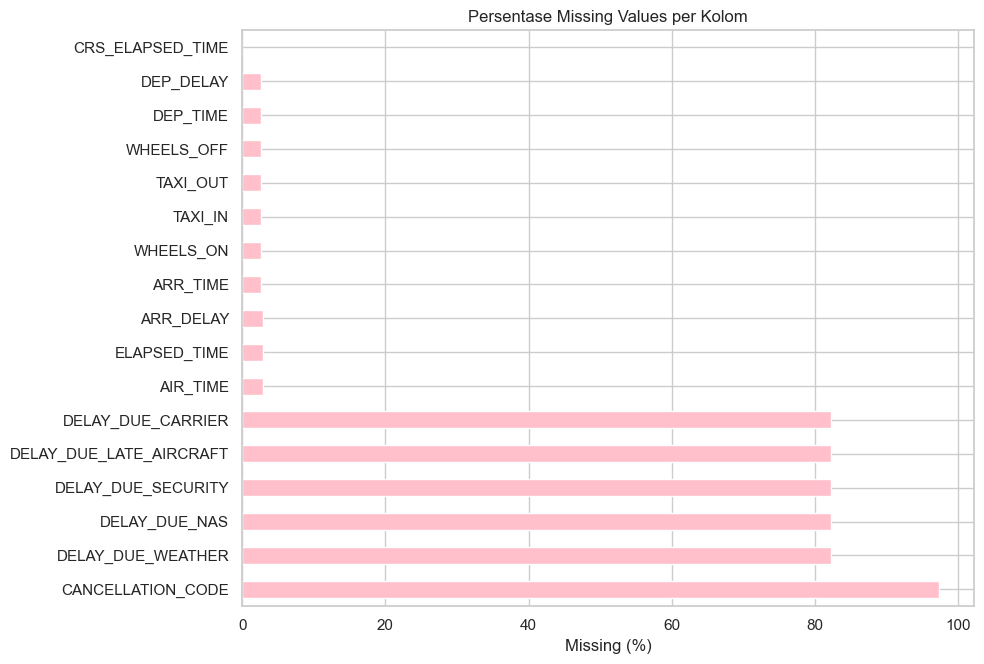

In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

print(f'Kolom dengan missing values: {len(missing_df)} dari {len(df.columns)} kolom\n')
print(missing_df.to_string())

# Visualisasi
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.4)))
    missing_df['Missing (%)'].plot(kind='barh', ax=ax, color='pink')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Persentase Missing Values per Kolom')
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=120)
    plt.show()

## 5. Sparsity Analysis

Mengukur tingkat kekosongan data (sparsity) pada dataset. Analisis ini diperlukan untuk mengetahui seberapa besar proporsi data yang hilang dan memenuhi bagian "Aspek Khusus Dataset" pada laporan.

In [8]:
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()

sparsity = (missing_cells / total_cells) * 100

print("SPARSITY ANALYSIS")

print(f"Total Cells   : {total_cells:,}")
print(f"Missing Cells : {missing_cells:,}")
print(f"Sparsity      : {sparsity:.2f}%")

SPARSITY ANALYSIS
Total Cells   : 96,000,000
Missing Cells : 16,062,854
Sparsity      : 16.73%


## 6. Outlier Analysis

Mengidentifikasi nilai ekstrem pada atribut yang nantinya digunakan sebagai measure pada Fact Table. Informasi ini penting untuk memahami karakteristik data dan menjelaskan adanya penerbangan dengan keterlambatan atau jarak yang sangat tinggi.

In [9]:
measure_cols = [
    'DEP_DELAY',
    'ARR_DELAY',
    'DISTANCE',
    'AIR_TIME'
]

for col in measure_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        ((df[col] < lower) |
         (df[col] > upper))
    ).sum()

    print(f"\n{col}")
    print(f"Jumlah Outlier : {outlier_count:,}")
    print(
        f"Persentase : "
        f"{outlier_count/len(df)*100:.2f}%"
    )


DEP_DELAY
Jumlah Outlier : 392,850
Persentase : 13.10%

ARR_DELAY
Jumlah Outlier : 258,240
Persentase : 8.61%

DISTANCE
Jumlah Outlier : 168,407
Persentase : 5.61%

AIR_TIME
Jumlah Outlier : 148,328
Persentase : 4.94%


## 7. Rentang Waktu & Distribusi Data

Memastikan dataset memenuhi syarat span waktu yang ditentukan pada proyek.

In [10]:
# Pastikan kolom tanggal bertipe datetime
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

print(f'Tanggal paling awal : {df["FL_DATE"].min().date()}')
print(f'Tanggal paling akhir: {df["FL_DATE"].max().date()}')
print(f'Rentang waktu       : {(df["FL_DATE"].max() - df["FL_DATE"].min()).days} hari')
print(f'Jumlah tahun        : {df["FL_DATE"].dt.year.nunique()} tahun ({sorted(df["FL_DATE"].dt.year.unique())})')

Tanggal paling awal : 2019-01-01
Tanggal paling akhir: 2023-08-31
Rentang waktu       : 1703 hari
Jumlah tahun        : 5 tahun ([np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)])


## 8. Visualisasi Distribusi Data

Distribusi penerbangan per bulan

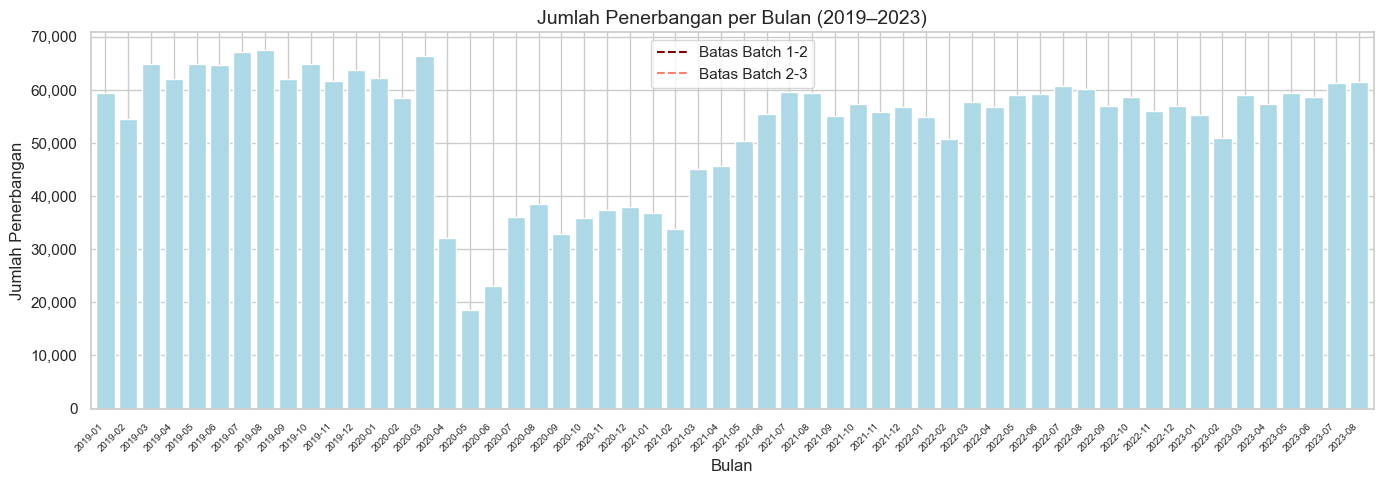

In [11]:
df['YearMonth'] = df['FL_DATE'].dt.to_period('M')
monthly_counts = df.groupby('YearMonth').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_counts.plot(kind='bar', ax=ax, color='lightblue', width=0.8)
ax.set_title('Jumlah Penerbangan per Bulan (2019–2023)', fontsize=14)
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Penerbangan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Garis pemisah batch
ax.axvline(x=monthly_counts.index.get_loc('2020-03'), color='maroon', linestyle='--', linewidth=1.5, label='Batas Batch 1-2')
ax.axvline(x=monthly_counts.index.get_loc('2021-12'), color='salmon', linestyle='--', linewidth=1.5, label='Batas Batch 2-3')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('distribusi_bulanan.png', dpi=120)
plt.show()

Distribusi maskapai

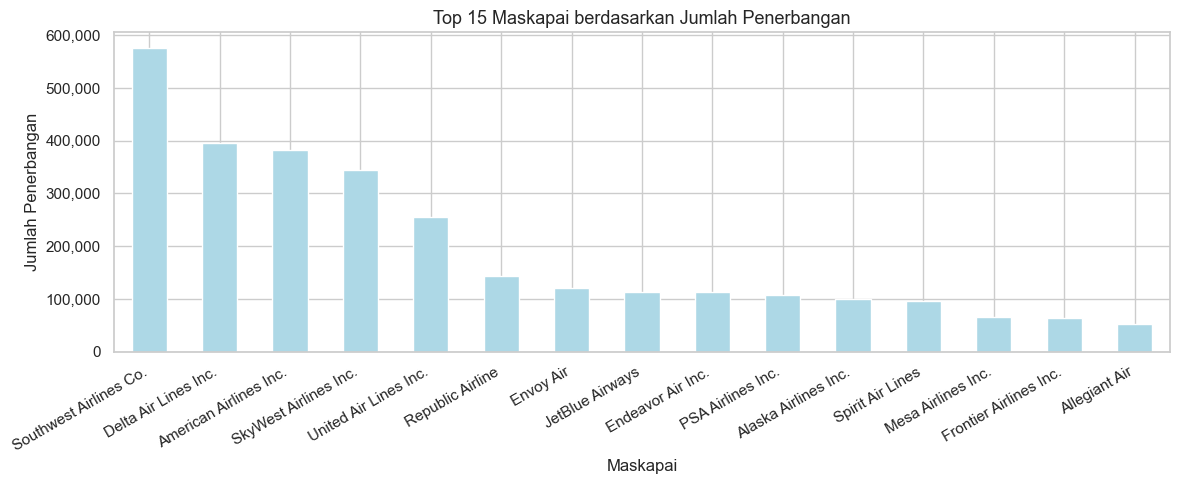

In [12]:
airline_col = 'AIRLINE' if 'AIRLINE' in df.columns else 'AIRLINE_CODE'
top_airlines = df[airline_col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_airlines.plot(kind='bar', ax=ax, color='lightblue')
ax.set_title('Top 15 Maskapai berdasarkan Jumlah Penerbangan', fontsize=13)
ax.set_xlabel('Maskapai')
ax.set_ylabel('Jumlah Penerbangan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('distribusi_maskapai.png', dpi=120)
plt.show()

Distribusi keterlambatan

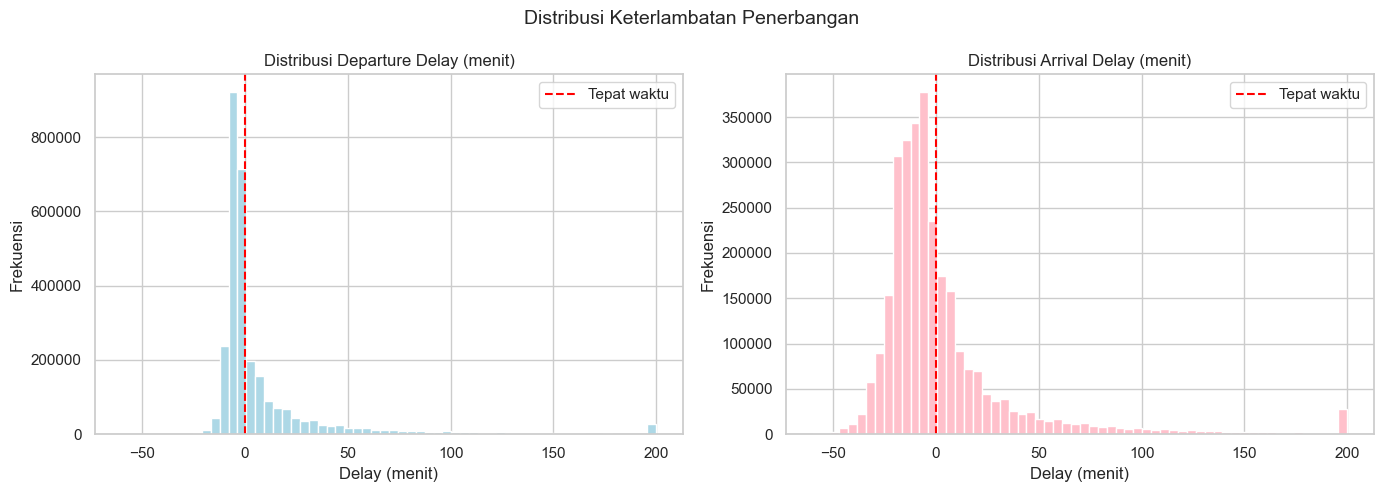

Rata-rata departure delay : 10.12 menit
Rata-rata arrival delay   : 4.26 menit
% penerbangan terlambat   : 34.0%
% penerbangan dibatalkan  : 2.64%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dep_delay = df['DEP_DELAY'].dropna()
dep_delay_clipped = dep_delay.clip(-60, 200)
axes[0].hist(dep_delay_clipped, bins=60, color='lightblue', edgecolor='white')
axes[0].set_title('Distribusi Departure Delay (menit)')
axes[0].set_xlabel('Delay (menit)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(0, color='red', linestyle='--', label='Tepat waktu')
axes[0].legend()

arr_delay = df['ARR_DELAY'].dropna()
arr_delay_clipped = arr_delay.clip(-60, 200)
axes[1].hist(arr_delay_clipped, bins=60, color='pink', edgecolor='white')
axes[1].set_title('Distribusi Arrival Delay (menit)')
axes[1].set_xlabel('Delay (menit)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(0, color='red', linestyle='--', label='Tepat waktu')
axes[1].legend()

plt.suptitle('Distribusi Keterlambatan Penerbangan', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi_delay.png', dpi=120)
plt.show()

print(f'Rata-rata departure delay : {dep_delay.mean():.2f} menit')
print(f'Rata-rata arrival delay   : {arr_delay.mean():.2f} menit')
print(f'% penerbangan terlambat   : {(dep_delay > 0).mean()*100:.1f}%')
print(f'% penerbangan dibatalkan  : {df["CANCELLED"].mean()*100:.2f}%')

# **Pembagian Dataset ke 3 Batch**

Dataset dibagi menjadi tiga batch berdasarkan rentang waktu yang berbeda untuk mensimulasikan proses periodic extraction pada data warehouse. Pembagian ini bertujuan untuk menggambarkan proses pengambilan data secara bertahap dari sumber data operasional ke staging area sebelum dilakukan transformasi dan loading.

### 1. Definisi batas waktu batch

In [14]:
BATCH_CONFIG = [
    {
        'name': 'batch_1',
        'label': 'Batch Periode Awal',
        'start': '2019-01-01',
        'end': '2020-03-31'
    },
    {
        'name': 'batch_2',
        'label': 'Batch Periode Menengah',
        'start': '2020-04-01',
        'end': '2021-12-31'
    },
    {
        'name': 'batch_3',
        'label': 'Batch Periode Akhir',
        'start': '2022-01-01',
        'end': '2023-12-31'
    }
]

batches = {}
print('=' * 60)
print('PEMBAGIAN BATCH')
print('=' * 60)

for cfg in BATCH_CONFIG:
    mask = (df['FL_DATE'] >= cfg['start']) & (df['FL_DATE'] <= cfg['end'])
    batch_df = df[mask].copy()
    batches[cfg['name']] = batch_df

    print(f"\n{cfg['name'].upper()} — {cfg['label']}")
    print(f"   Periode  : {cfg['start']} s/d {cfg['end']}")
    print(f"   Baris    : {len(batch_df):,}")
    print(f"   % total  : {len(batch_df)/len(df)*100:.1f}%")

print(f'Total baris semua batch: {sum(len(b) for b in batches.values()):,}')
print(f'Total baris dataset   : {len(df):,}')

PEMBAGIAN BATCH

BATCH_1 — Batch Periode Awal
   Periode  : 2019-01-01 s/d 2020-03-31
   Baris    : 944,617
   % total  : 31.5%

BATCH_2 — Batch Periode Menengah
   Periode  : 2020-04-01 s/d 2021-12-31
   Baris    : 904,039
   % total  : 30.1%

BATCH_3 — Batch Periode Akhir
   Periode  : 2022-01-01 s/d 2023-12-31
   Baris    : 1,151,344
   % total  : 38.4%
Total baris semua batch: 3,000,000
Total baris dataset   : 3,000,000


 ### 2. Visualisasi perbandingan ukuran batch

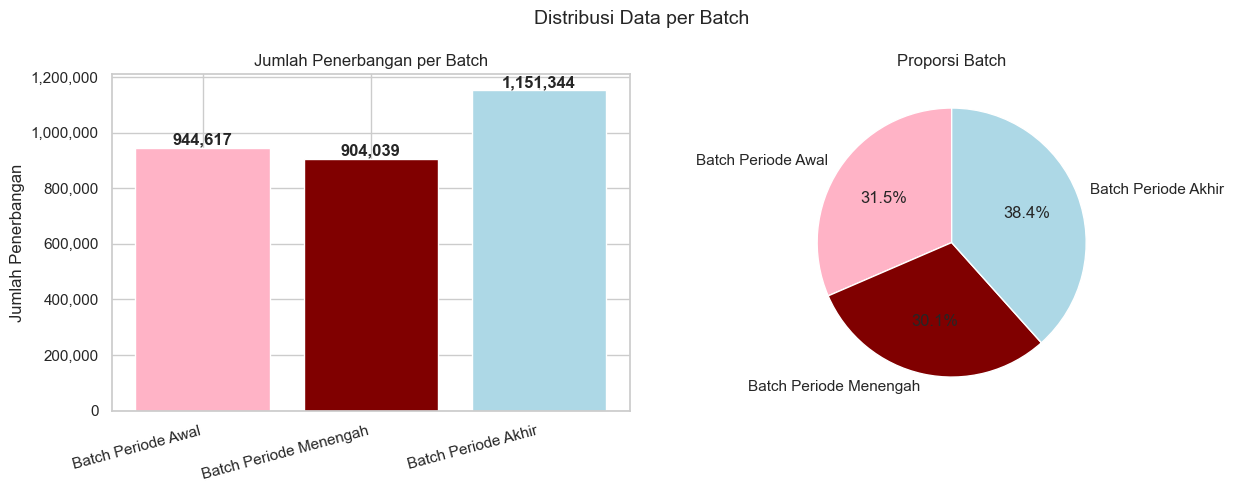

In [15]:

batch_sizes = {cfg['label']: len(batches[cfg['name']]) for cfg in BATCH_CONFIG}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#FFB3C6', '#800000', '#ADD8E6']
bars = axes[0].bar(batch_sizes.keys(), batch_sizes.values(), color=colors)
axes[0].set_title('Jumlah Penerbangan per Batch')
axes[0].set_ylabel('Jumlah Penerbangan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, batch_sizes.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=15, ha='right')

axes[1].pie(batch_sizes.values(), labels=batch_sizes.keys(),
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Batch')

plt.suptitle('Distribusi Data per Batch', fontsize=14)
plt.tight_layout()
plt.savefig('batch_distribution.png', dpi=120)
plt.show()

## 3. Extract — Simpan Batch ke Staging Area


Menyimpan masing-masing batch ke staging area.

In [16]:
def extract_batch(df_batch: pd.DataFrame, batch_name: str, staging_dir: str) -> str:
    output_path = os.path.join(staging_dir, f'{batch_name}_raw.csv')
    df_batch.to_csv(output_path, index=False)
    size_mb = os.path.getsize(output_path) / 1024**2
    print(f'{batch_name}_raw.csv — {len(df_batch):,} baris | {size_mb:.1f} MB → {output_path}')
    return output_path

print('EXTRACT — Menyimpan Batch ke Staging Area')

extracted_paths = {}
for cfg in BATCH_CONFIG:
    path = extract_batch(batches[cfg['name']], cfg['name'], STAGING_DIR)
    extracted_paths[cfg['name']] = path

print(f'\nSemua batch tersimpan di folder: {os.path.abspath(STAGING_DIR)}/')

EXTRACT — Menyimpan Batch ke Staging Area
batch_1_raw.csv — 944,617 baris | 192.8 MB → Pembagian Batch\batch_1_raw.csv
batch_2_raw.csv — 904,039 baris | 183.3 MB → Pembagian Batch\batch_2_raw.csv
batch_3_raw.csv — 1,151,344 baris | 235.3 MB → Pembagian Batch\batch_3_raw.csv

Semua batch tersimpan di folder: h:\SEMESTER 4\DataWarehouse\Projek Datwar\Pembagian Batch/


## 4. Verifikasi Hasil Ekstraksi

In [17]:
print('Membaca ulang dari staging untuk konfirmasi\n')
print(f'{"Batch":<12} {"Baris":>10} {"Kolom":>8} {"Tanggal Min":<15} {"Tanggal Maks":<15} {"Ukuran":>10}')
print('-' * 75)

for cfg in BATCH_CONFIG:
    path = extracted_paths[cfg['name']]
    verify_df = pd.read_csv(path, low_memory=False, parse_dates=['FL_DATE'])
    size_mb = os.path.getsize(path) / 1024**2
    print(
        f"{cfg['name']:<12}"
        f"{len(verify_df):>10,}"
        f"{len(verify_df.columns):>8}"
        f"  {str(verify_df['FL_DATE'].min().date()):<15}"
        f"{str(verify_df['FL_DATE'].max().date()):<15}"
        f"{size_mb:>8.1f} MB"
    )

print('\nEkstraksi selesai!')

Membaca ulang dari staging untuk konfirmasi

Batch             Baris    Kolom Tanggal Min     Tanggal Maks        Ukuran
---------------------------------------------------------------------------
batch_1        944,617      33  2019-01-01     2020-03-31        192.8 MB
batch_2        904,039      33  2020-04-01     2021-12-31        183.3 MB
batch_3      1,151,344      33  2022-01-01     2023-08-31        235.3 MB

Ekstraksi selesai!


# **Data Cleaning**

Menghapus duplikasi dan menangani missing value.

## 1. Menghapus Duplikasi

In [18]:
print("DATA CLEANING")

print("Jumlah data awal :", len(df))

# Hapus duplikat
duplicate_count = df.duplicated().sum()

print("Jumlah duplikat :", duplicate_count)

df = df.drop_duplicates()

print("Jumlah data setelah cleaning :", len(df))

DATA CLEANING
Jumlah data awal : 3000000
Jumlah duplikat : 0
Jumlah data setelah cleaning : 3000000


## 2. Menangani Missing Value

In [19]:
# DELAY & FLIGHT MEASURES
# Missing value pada atribut berikut umumnya berasal dari
# penerbangan yang dibatalkan. Untuk keperluan analisis dan
# pembentukan Fact Table, nilai kosong direpresentasikan
# sebagai 0.

measure_cols = [
    'DEP_DELAY',
    'ARR_DELAY',
    'AIR_TIME'
]

for col in measure_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Penyebab delay
# Jika tidak ada penyebab delay yang tercatat maka dianggap
# tidak terjadi delay dari faktor tersebut.

delay_cause_cols = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

for col in delay_cause_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Status pembatalan
# NULL pada CANCELLATION_CODE berarti penerbangan tidak
# dibatalkan.
df['CANCELLATION_CODE'] = (
    df['CANCELLATION_CODE']
    .fillna('NOT_CANCELLED')
)

print("Missing value berhasil ditangani")

Missing value berhasil ditangani


## 3. Data Quality Check

In [20]:
print("DATA QUALITY CHECK")
print(
    f"Remaining Missing Value : "
    f"{df.isnull().sum().sum():,}"
)

print(
    f"Duplicate Data : "
    f"{df.duplicated().sum():,}"
)

remaining_missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = (
    remaining_missing[
        remaining_missing > 0
    ]
)

display(remaining_missing)

DATA QUALITY CHECK
Remaining Missing Value : 561,269
Duplicate Data : 0


ELAPSED_TIME        86198
WHEELS_ON           79944
TAXI_IN             79944
ARR_TIME            79942
WHEELS_OFF          78806
TAXI_OUT            78806
DEP_TIME            77615
CRS_ELAPSED_TIME       14
dtype: int64

Tidak ditemukan data duplikat pada dataset. Sebanyak 561.269 missing value masih tersisa pada beberapa atribut operasional penerbangan seperti `DEP_TIME`, `ARR_TIME`, `WHEELS_ON`, `WHEELS_OFF`, `TAXI_IN`, `TAXI_OUT`, dan `ELAPSED_TIME`. Missing value tersebut umumnya disebabkan oleh penerbangan yang dibatalkan sehingga informasi terkait aktivitas penerbangan tidak tersedia. Karena kolom-kolom tersebut tidak digunakan dalam pembentukan Fact Table maupun Dimension Table, nilai kosong dipertahankan untuk menjaga representasi kondisi bisnis yang sebenarnya.

# **Time Granularity**

Membentuk dimensi waktu yang akan digunakan dalam Data Warehouse.

In [21]:
print("TIME DIMENSION")
df['YEAR'] = df['FL_DATE'].dt.year

df['QUARTER'] = df['FL_DATE'].dt.quarter

df['MONTH'] = df['FL_DATE'].dt.month

df['MONTH_NAME'] = df['FL_DATE'].dt.month_name()

df['DAY'] = df['FL_DATE'].dt.day

df['DAY_NAME'] = df['FL_DATE'].dt.day_name()

df['WEEKDAY'] = np.where(
    df['DAY_NAME'].isin(['Saturday','Sunday']),
    'Weekend',
    'Weekday'
)

df.head()

TIME DIMENSION


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YearMonth,YEAR,QUARTER,MONTH,MONTH_NAME,DAY,DAY_NAME,WEEKDAY
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,0.0,2019-01,2019,1,1,January,9,Wednesday,Weekday
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,0.0,2022-11,2022,4,11,November,19,Saturday,Weekend
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,0.0,2022-07,2022,3,7,July,22,Friday,Weekday
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,0.0,2023-03,2023,1,3,March,6,Monday,Weekday
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,0.0,2020-02,2020,1,2,February,23,Sunday,Weekend


# **Delay Category**

Mengubah delay menjadi kategori bisnis yang lebih mudah dianalisis.

In [22]:
def delay_category(delay):

    if delay <= 0:
        return "On Time"

    elif delay <= 15:
        return "Minor Delay"

    elif delay <= 60:
        return "Moderate Delay"

    else:
        return "Severe Delay"


df['DELAY_CATEGORY'] = (
    df['ARR_DELAY']
    .apply(delay_category)
)

df['DELAY_CATEGORY'].value_counts()

DELAY_CATEGORY
On Time           2021853
Minor Delay        462858
Moderate Delay     340154
Severe Delay       175135
Name: count, dtype: int64

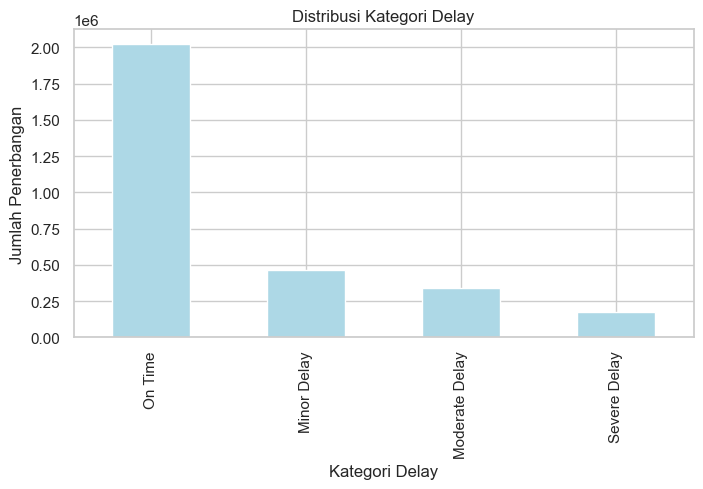

In [23]:
delay_dist = (
    df['DELAY_CATEGORY']
    .value_counts()
)

plt.figure(figsize=(8,4))

delay_dist.plot(
    kind='bar',
    color='lightblue'
)

plt.title('Distribusi Kategori Delay')
plt.xlabel('Kategori Delay')
plt.ylabel('Jumlah Penerbangan')

plt.show()

# **Imbalance Analysis**

In [24]:
print(
    df['CANCELLED']
    .value_counts(
        normalize=True
    ) * 100
)

print(
    df['DELAY_CATEGORY']
    .value_counts(
        normalize=True
    ) * 100
)

CANCELLED
0.0    97.362
1.0     2.638
Name: proportion, dtype: float64
DELAY_CATEGORY
On Time           67.395100
Minor Delay       15.428600
Moderate Delay    11.338467
Severe Delay       5.837833
Name: proportion, dtype: float64


# **Data Integration**

Menyeragamkan format alasan pembatalan penerbangan.

In [25]:
cancel_reason = {
    'A':'Carrier',
    'B':'Weather',
    'C':'NAS',
    'D':'Security',
    'NOT_CANCELLED':'Not Cancelled'
}

df['CANCELLATION_REASON'] = (
    df['CANCELLATION_CODE']
    .map(cancel_reason)
)

# **Dimension Tables**

## 1. Dim_Date

In [26]:
dim_date = (
    df[
        [
            'FL_DATE',
            'YEAR',
            'QUARTER',
            'MONTH',
            'MONTH_NAME',
            'DAY',
            'DAY_NAME',
            'WEEKDAY'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_date.insert(
    0,
    'DATE_ID',
    range(1, len(dim_date)+1)
)

dim_date.head()

,DATE_ID,FL_DATE,YEAR,QUARTER,MONTH,MONTH_NAME,DAY,DAY_NAME,WEEKDAY
0,1,2019-01-09,2019,1,1,January,9,Wednesday,Weekday
1,2,2022-11-19,2022,4,11,November,19,Saturday,Weekend
2,3,2022-07-22,2022,3,7,July,22,Friday,Weekday
3,4,2023-03-06,2023,1,3,March,6,Monday,Weekday
4,5,2020-02-23,2020,1,2,February,23,Sunday,Weekend


## 2. Dim_Airline

In [27]:
dim_airline = (
    df[
        [
            'AIRLINE_CODE',
            'AIRLINE'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_airline.insert(
    0,
    'AIRLINE_ID',
    range(1, len(dim_airline)+1)
)

dim_airline.head()

,AIRLINE_ID,AIRLINE_CODE,AIRLINE
0,1,UA,United Air Lines Inc.
1,2,DL,Delta Air Lines Inc.
2,3,NK,Spirit Air Lines
3,4,WN,Southwest Airlines Co.
4,5,AA,American Airlines Inc.


## 3. Dim_Delay

In [28]:
print("="*60)
print("DIM_DELAY")
print("="*60)

dim_delay = (
    df[['DELAY_CATEGORY']]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_delay.insert(
    0,
    'DELAY_ID',
    range(1, len(dim_delay)+1)
)

dim_delay.head()

DIM_DELAY


,DELAY_ID,DELAY_CATEGORY
0,1,On Time
1,2,Moderate Delay
2,3,Severe Delay
3,4,Minor Delay


## 4. Dim_Origin

In [29]:
dim_origin = (
    df[
        [
            'ORIGIN',
            'ORIGIN_CITY'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_origin.insert(
    0,
    'ORIGIN_ID',
    range(1, len(dim_origin)+1)
)

dim_origin.head()

,ORIGIN_ID,ORIGIN,ORIGIN_CITY
0,1,FLL,"Fort Lauderdale, FL"
1,2,MSP,"Minneapolis, MN"
2,3,DEN,"Denver, CO"
3,4,MCO,"Orlando, FL"
4,5,DAL,"Dallas, TX"


## 5. Dim_Destination

In [30]:
dim_destination = (
    df[
        [
            'DEST',
            'DEST_CITY'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_destination.insert(
    0,
    'DESTINATION_ID',
    range(1, len(dim_destination)+1)
)

dim_destination.head()

,DESTINATION_ID,DEST,DEST_CITY
0,1,EWR,"Newark, NJ"
1,2,SEA,"Seattle, WA"
2,3,MSP,"Minneapolis, MN"
3,4,SFO,"San Francisco, CA"
4,5,DFW,"Dallas/Fort Worth, TX"


## 6. Dim_Cancellation

In [31]:
dim_cancellation = (
    df[
        [
            'CANCELLATION_CODE',
            'CANCELLATION_REASON'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_cancellation.insert(
    0,
    'CANCELLATION_ID',
    range(1, len(dim_cancellation)+1)
)

dim_cancellation.head()

,CANCELLATION_ID,CANCELLATION_CODE,CANCELLATION_REASON
0,1,NOT_CANCELLED,Not Cancelled
1,2,D,Security
2,3,B,Weather
3,4,A,Carrier
4,5,C,NAS


## 7. Dimension Summary

In [32]:
dimension_summary = pd.DataFrame({
    'Dimension':[
        'Dim_Date',
        'Dim_Airline',
        'Dim_Delay',
        'Dim_Origin',
        'Dim_Destination',
        'Dim_Cancellation'
    ],
    'Rows':[
        len(dim_date),
        len(dim_airline),
        len(dim_delay),
        len(dim_origin),
        len(dim_destination),
        len(dim_cancellation)
    ]
})

display(dimension_summary)

,Dimension,Rows
0,Dim_Date,1704
1,Dim_Airline,18
2,Dim_Delay,4
3,Dim_Origin,381
4,Dim_Destination,381
5,Dim_Cancellation,5


# **Pembuatan Fact Table**

In [33]:
fact_flight = df.copy()

## 1. Join Date Key

In [34]:
fact_flight = fact_flight.merge(
    dim_date[['DATE_ID','FL_DATE']],
    on='FL_DATE',
    how='left'
)

## 2. Join Airline Key

In [35]:
fact_flight = fact_flight.merge(
    dim_airline[['AIRLINE_ID','AIRLINE_CODE']],
    on='AIRLINE_CODE',
    how='left'
)

## 3. Join Delay Key

In [36]:
fact_flight = fact_flight.merge(
    dim_delay,
    on='DELAY_CATEGORY',
    how='left'
)

## 4. Join Origin Key

In [37]:
fact_flight = fact_flight.merge(
    dim_origin[['ORIGIN_ID','ORIGIN']],
    on='ORIGIN',
    how='left'
)

## 5. Join Destination Key

In [38]:
fact_flight = fact_flight.merge(
    dim_destination[['DESTINATION_ID','DEST']],
    on='DEST',
    how='left'
)

## 6. Join Cancellation Key

In [39]:
fact_flight = fact_flight.merge(
    dim_cancellation[
        ['CANCELLATION_ID','CANCELLATION_CODE']
    ],
    on='CANCELLATION_CODE',
    how='left'
)

# **Primary Key Fact Table**

In [40]:
fact_flight.insert(
    0,
    'FLIGHT_FACT_ID',
    range(
        1,
        len(fact_flight)+1
    )
)

# **Fact Final**

In [41]:
fact_flight = fact_flight[
    [
        'FLIGHT_FACT_ID',
        'DATE_ID',
        'AIRLINE_ID',
        'ORIGIN_ID',
        'DESTINATION_ID',
        'CANCELLATION_ID',
        'DELAY_ID',

        'DEP_DELAY',
        'ARR_DELAY',
        'DISTANCE',
        'AIR_TIME',
        'CANCELLED'
    ]
]

## **Star Schema Validation**

In [42]:
fk_cols = [
    'DATE_ID',
    'AIRLINE_ID',
    'ORIGIN_ID',
    'DESTINATION_ID',
    'CANCELLATION_ID',
    'DELAY_ID'
]

print(
    fact_flight[fk_cols]
    .isnull()
    .sum()
)

DATE_ID            0
AIRLINE_ID         0
ORIGIN_ID          0
DESTINATION_ID     0
CANCELLATION_ID    0
DELAY_ID           0
dtype: int64


Hasil validasi menunjukkan bahwa seluruh foreign key pada tabel Fact_Flight memiliki nilai null sebanyak 0. Hal ini menandakan bahwa setiap record pada tabel fakta telah berhasil terhubung dengan tabel dimensi yang sesuai sehingga integritas referensial dalam Star Schema terjaga. Dengan demikian, struktur data warehouse yang dibangun telah siap digunakan pada tahap loading dan analisis OLAP.

# **Fact Table Summary**

In [43]:
print(
    f"Jumlah Record : {len(fact_flight):,}"
)

display(
    fact_flight.describe()
)

Jumlah Record : 3,001,059


,FLIGHT_FACT_ID,DATE_ID,AIRLINE_ID,ORIGIN_ID,DESTINATION_ID,CANCELLATION_ID,DELAY_ID,DEP_DELAY,ARR_DELAY,DISTANCE,AIR_TIME,CANCELLED
count,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06,3.001059e+06
mean,1.500530e+06,8.303289e+02,6.647643e+00,5.251937e+01,5.503974e+01,1.055449e+00,1.693045e+00,9.861536e+00,4.140717e+00,8.092742e+02,1.090724e+02,2.639602e-02
std,8.663313e+05,4.837687e+02,4.557004e+00,5.954726e+01,5.855630e+01,3.693443e-01,1.120372e+00,4.863421e+01,5.043687e+01,5.878103e+02,7.125123e+01,1.603099e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,-9.600000e+01,2.900000e+01,0.000000e+00,0.000000e+00
25%,7.502655e+05,4.140000e+02,4.000000e+00,1.400000e+01,1.300000e+01,1.000000e+00,1.000000e+00,-6.000000e+00,-1.500000e+01,3.770000e+02,5.900000e+01,0.000000e+00
50%,1.500530e+06,8.240000e+02,5.000000e+00,3.300000e+01,3.800000e+01,1.000000e+00,1.000000e+00,-2.000000e+00,-6.000000e+00,6.510000e+02,9.300000e+01,0.000000e+00
75%,2.250794e+06,1.241000e+03,1.200000e+01,6.600000e+01,7.700000e+01,1.000000e+00,2.000000e+00,6.000000e+00,6.000000e+00,1.046000e+03,1.400000e+02,0.000000e+00
max,3.001059e+06,1.704000e+03,1.800000e+01,3.810000e+02,3.810000e+02,5.000000e+00,4.000000e+00,2.966000e+03,2.934000e+03,5.812000e+03,6.920000e+02,1.000000e+00


# **Simpan Hasil Transform**

In [44]:
TRANSFORM_DIR = "Transform_Result"
os.makedirs(TRANSFORM_DIR, exist_ok=True)

dim_date.to_csv(
    f"{TRANSFORM_DIR}/dim_date.csv",
    index=False
)

dim_airline.to_csv(
    f"{TRANSFORM_DIR}/dim_airline.csv",
    index=False
)

dim_delay.to_csv(
    f"{TRANSFORM_DIR}/dim_delay.csv",
    index=False
)

dim_origin.to_csv(
    f"{TRANSFORM_DIR}/dim_origin.csv",
    index=False
)

dim_destination.to_csv(
    f"{TRANSFORM_DIR}/dim_destination.csv",
    index=False
)

dim_cancellation.to_csv(
    f"{TRANSFORM_DIR}/dim_cancellation.csv",
    index=False
)

fact_flight.to_csv(
    f"{TRANSFORM_DIR}/fact_flight.csv",
    index=False
)

print("Transform berhasil")
print("Semua tabel siap untuk proses LOAD")

Transform berhasil
Semua tabel siap untuk proses LOAD


# **Load Ke PostgreSQL**

mengimplementasikan Data Warehouse ke dalam PostgreSQL. Data hasil ETL dari tahap sebelumnya dimuat ke PostgreSQL agar dapat digunakan untuk analisis dan OLAP.

## 1. Buat Koneksi PostgreSQL

Tahap ini bertujuan untuk menghubungkan Python dengan database PostgreSQL yang  menggunakan SQLAlchemy dan digunakan sebagai media penyimpanan Data Warehouse. Koneksi diuji menggunakan query sederhana untuk memastikan database dapat diakses dengan baik.

In [45]:
from sqlalchemy import create_engine, text

DB_USER = "postgres"
DB_PASSWORD = "Salza1306"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "postgres"

try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )

    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))

    print("Koneksi PostgreSQL berhasil")

except Exception as e:
    print("Koneksi gagal")
    print(e)

Koneksi PostgreSQL berhasil


In [46]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    print(result.fetchone())

('PostgreSQL 18.0 on x86_64-windows, compiled by msvc-19.44.35217, 64-bit',)


In [47]:
print(dim_date.columns.tolist())

print(dim_airline.columns.tolist())

print(dim_delay.columns.tolist())

print(dim_origin.columns.tolist())

print(dim_destination.columns.tolist())

print(dim_cancellation.columns.tolist())

print(fact_flight.columns.tolist())

['DATE_ID', 'FL_DATE', 'YEAR', 'QUARTER', 'MONTH', 'MONTH_NAME', 'DAY', 'DAY_NAME', 'WEEKDAY']
['AIRLINE_ID', 'AIRLINE_CODE', 'AIRLINE']
['DELAY_ID', 'DELAY_CATEGORY']
['ORIGIN_ID', 'ORIGIN', 'ORIGIN_CITY']
['DESTINATION_ID', 'DEST', 'DEST_CITY']
['CANCELLATION_ID', 'CANCELLATION_CODE', 'CANCELLATION_REASON']
['FLIGHT_FACT_ID', 'DATE_ID', 'AIRLINE_ID', 'ORIGIN_ID', 'DESTINATION_ID', 'CANCELLATION_ID', 'DELAY_ID', 'DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'AIR_TIME', 'CANCELLED']


## 2. Buat Tabel di PostgreSQL

Pada tahap ini dibuat tabel dimensi dan tabel fakta sesuai rancangan Star Schema. Struktur tabel yang dibuat akan digunakan sebagai penyimpanan data hasil proses ETL.

In [48]:
from sqlalchemy import text

create_tables_sql = """

DROP TABLE IF EXISTS fact_flight CASCADE;
DROP TABLE IF EXISTS dim_date CASCADE;
DROP TABLE IF EXISTS dim_airline CASCADE;
DROP TABLE IF EXISTS dim_delay CASCADE;
DROP TABLE IF EXISTS dim_origin CASCADE;
DROP TABLE IF EXISTS dim_destination CASCADE;
DROP TABLE IF EXISTS dim_cancellation CASCADE;

CREATE TABLE dim_date (
    date_id INT PRIMARY KEY,
    fl_date DATE,
    year INT,
    quarter INT,
    month INT,
    month_name VARCHAR(20),
    day INT,
    day_name VARCHAR(20),
    weekday VARCHAR(20)
);

CREATE TABLE dim_airline (
    airline_id INT PRIMARY KEY,
    airline_code VARCHAR(10),
    airline VARCHAR(100)
);

CREATE TABLE dim_delay (
    delay_id INT PRIMARY KEY,
    delay_category VARCHAR(30)
);

CREATE TABLE dim_origin (
    origin_id INT PRIMARY KEY,
    origin VARCHAR(10),
    origin_city VARCHAR(100)
);

CREATE TABLE dim_destination (
    destination_id INT PRIMARY KEY,
    dest VARCHAR(10),
    dest_city VARCHAR(100)
);

CREATE TABLE dim_cancellation (
    cancellation_id INT PRIMARY KEY,
    cancellation_code VARCHAR(20),
    cancellation_reason VARCHAR(100)
);

CREATE TABLE fact_flight (

    flight_fact_id BIGINT PRIMARY KEY,

    date_id INT NOT NULL,
    airline_id INT NOT NULL,
    origin_id INT NOT NULL,
    destination_id INT NOT NULL,
    cancellation_id INT NOT NULL,
    delay_id INT NOT NULL,

    dep_delay FLOAT,
    arr_delay FLOAT,
    distance FLOAT,
    air_time FLOAT,
    cancelled FLOAT,

    CONSTRAINT fk_date
        FOREIGN KEY (date_id)
        REFERENCES dim_date(date_id),

    CONSTRAINT fk_airline
        FOREIGN KEY (airline_id)
        REFERENCES dim_airline(airline_id),

    CONSTRAINT fk_origin
        FOREIGN KEY (origin_id)
        REFERENCES dim_origin(origin_id),

    CONSTRAINT fk_destination
        FOREIGN KEY (destination_id)
        REFERENCES dim_destination(destination_id),

    CONSTRAINT fk_cancellation
        FOREIGN KEY (cancellation_id)
        REFERENCES dim_cancellation(cancellation_id),

    CONSTRAINT fk_delay
        FOREIGN KEY (delay_id)
        REFERENCES dim_delay(delay_id)
);

"""

with engine.connect() as conn:
    conn.execute(text(create_tables_sql))
    conn.commit()

print("Semua tabel berhasil dibuat")

Semua tabel berhasil dibuat


## 3. Load Data ke PostgreSQL

Data hasil transformasi dimasukkan ke dalam tabel dimensi pada PostgreSQL. Sebelum proses load dilakukan, nama kolom diseragamkan menjadi huruf kecil agar sesuai dengan struktur tabel database.

In [49]:
dim_date.columns = dim_date.columns.str.lower()

dim_airline.columns = dim_airline.columns.str.lower()

dim_delay.columns = dim_delay.columns.str.lower()

dim_origin.columns = dim_origin.columns.str.lower()

dim_destination.columns = dim_destination.columns.str.lower()

dim_cancellation.columns = dim_cancellation.columns.str.lower()

fact_flight.columns = fact_flight.columns.str.lower()

In [50]:
print(dim_date.columns.tolist())

['date_id', 'fl_date', 'year', 'quarter', 'month', 'month_name', 'day', 'day_name', 'weekday']


In [51]:
print("LOAD DIMENSION TABLES")

dim_date.to_sql(
    "dim_date",
    engine,
    if_exists="append",
    index=False
)

dim_airline.to_sql(
    "dim_airline",
    engine,
    if_exists="append",
    index=False
)

dim_delay.to_sql(
    "dim_delay",
    engine,
    if_exists="append",
    index=False
)

dim_origin.to_sql(
    "dim_origin",
    engine,
    if_exists="append",
    index=False
)

dim_destination.to_sql(
    "dim_destination",
    engine,
    if_exists="append",
    index=False
)

dim_cancellation.to_sql(
    "dim_cancellation",
    engine,
    if_exists="append",
    index=False
)

print("Dimension tables berhasil di-load")

LOAD DIMENSION TABLES
Dimension tables berhasil di-load


## 4. Load Fact Table

Tabel fakta dimuat ke PostgreSQL menggunakan metode chunking untuk mengakomodasi data berukuran besar, ehingga chunking membantu proses loading berjalan lebih stabil dan mengurangi penggunaan memori yang berlebihan. Proses ini bertujuan menyimpan seluruh transaksi penerbangan ke dalam Data Warehouse.

In [52]:
print("LOAD FACT TABLE")

fact_flight.to_sql(
    "fact_flight",
    engine,
    if_exists="append",
    index=False,
    chunksize=50000,
    method="multi"
)

print("Fact table berhasil di-load")

LOAD FACT TABLE
Fact table berhasil di-load


## 5. Validasi Load

Tahap ini dilakukan untuk memastikan seluruh data pada tabel fakta berhasil dimuat ke PostgreSQL tanpa kehilangan record selama proses loading.

In [53]:
with engine.connect() as conn:

    result = conn.execute(
        text("""
        SELECT COUNT(*)
        FROM fact_flight
        """)
    )

    total_rows = result.scalar()

print(
    f"Total Record Fact Table : "
    f"{total_rows:,}"
)

Total Record Fact Table : 3,001,059


## 6. Validasi Semua Tabel

Validasi dilakukan dengan menghitung jumlah record pada setiap tabel dimensi dan tabel fakta untuk memastikan proses loading berjalan dengan baik dan sesuai hasil transformasi.

In [54]:
tables = [
    "dim_date",
    "dim_airline",
    "dim_delay",
    "dim_origin",
    "dim_destination",
    "dim_cancellation",
    "fact_flight"
]

with engine.connect() as conn:

    for table in tables:

        result = conn.execute(
            text(
                f"SELECT COUNT(*) FROM {table}"
            )
        )

        print(
            f"{table:<20} : "
            f"{result.scalar():,}"
        )

dim_date             : 1,704
dim_airline          : 18
dim_delay            : 4
dim_origin           : 381
dim_destination      : 381
dim_cancellation     : 5
fact_flight          : 3,001,059


# **Implementasi Fitur PostgreSQL**

## 7. PostgreSQL Feature: Index

Index dibuat pada beberapa foreign key di tabel fakta untuk meningkatkan performa query, khususnya pada proses pencarian dan analisis data yang melibatkan relasi antar tabel.

In [55]:
from sqlalchemy import text

with engine.connect() as conn:

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_fact_date
        ON fact_flight(date_id);
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_fact_airline
        ON fact_flight(airline_id);
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_fact_origin
        ON fact_flight(origin_id);
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_fact_destination
        ON fact_flight(destination_id);
    """))

    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_fact_delay
        ON fact_flight(delay_id);
    """))

    conn.commit()

print("Index berhasil dibuat")

Index berhasil dibuat


Pada tabel fakta terdapat beberapa foreign key yang sering digunakan dalam proses analisis dan filtering data, yaitu date_id, airline_id, origin_id, destination_id, dan delay_id. Oleh karena itu, index dibuat pada kolom-kolom tersebut untuk mempercepat proses pencarian dan query yang melibatkan dimensi waktu, maskapai, bandara asal, bandara tujuan, dan kategori keterlambatan.

## 8. Materialized View

Materialized View digunakan untuk menyimpan hasil agregasi yang sering digunakan dalam analisis. Dengan cara ini, proses query dapat berjalan lebih cepat dibandingkan melakukan perhitungan ulang secara langsung pada tabel fakta.

In [56]:
from sqlalchemy import text

with engine.connect() as conn:

    conn.execute(text("""

    DROP MATERIALIZED VIEW IF EXISTS mv_airline_performance;

    CREATE MATERIALIZED VIEW mv_airline_performance AS

    SELECT
        a.airline,
        COUNT(*) AS total_flights,
        AVG(f.dep_delay) AS avg_dep_delay,
        AVG(f.arr_delay) AS avg_arr_delay,
        SUM(f.cancelled) AS total_cancelled

    FROM fact_flight f
    JOIN dim_airline a
        ON f.airline_id = a.airline_id

    GROUP BY a.airline

    """))

    conn.commit()

print("Materialized View berhasil dibuat")

Materialized View berhasil dibuat


## 9. PostgreSQL Extension

Extension PostgreSQL digunakan untuk menambah kemampuan database dalam melakukan monitoring dan optimasi performa query yang dijalankan.

In [57]:
from sqlalchemy import text

with engine.connect() as conn:

    conn.execute(
        text(
            "CREATE EXTENSION IF NOT EXISTS pg_stat_statements;"
        )
    )

    conn.commit()

print("Extension berhasil diaktifkan")

Extension berhasil diaktifkan


## 10. Benchmark Query Agregasi

Pengujian dilakukan untuk mengukur performa PostgreSQL dalam melakukan agregasi data terhadap lebih dari tiga juta record pada tabel fakta menggunakan EXPLAIN ANALYZE.

In [58]:
print("="*60)
print("BENCHMARK 1 - AGGREGATION QUERY")
print("="*60)

query_agg = """

EXPLAIN ANALYZE

SELECT
    airline_id,
    AVG(arr_delay)
FROM fact_flight
GROUP BY airline_id;

"""

with engine.connect() as conn:

    result = conn.execute(text(query_agg))

    for row in result:
        print(row[0])

BENCHMARK 1 - AGGREGATION QUERY
Finalize GroupAggregate  (cost=56817.29..56878.09 rows=200 width=12) (actual time=414.059..422.661 rows=18.00 loops=1)
  Group Key: airline_id
  Buffers: shared hit=15887 read=21178
  ->  Gather Merge  (cost=56817.29..56873.19 rows=480 width=36) (actual time=414.051..422.644 rows=54.00 loops=1)
        Workers Planned: 2
        Workers Launched: 2
        Buffers: shared hit=15887 read=21178
        ->  Sort  (cost=55817.26..55817.76 rows=200 width=36) (actual time=371.556..371.557 rows=18.00 loops=3)
              Sort Key: airline_id
              Sort Method: quicksort  Memory: 26kB
              Buffers: shared hit=15887 read=21178
              Worker 0:  Sort Method: quicksort  Memory: 26kB
              Worker 1:  Sort Method: quicksort  Memory: 26kB
              ->  Partial HashAggregate  (cost=55807.62..55809.62 rows=200 width=36) (actual time=371.526..371.530 rows=18.00 loops=3)
                    Group Key: airline_id
                    Ba

Hasil benchmark menunjukkan bahwa PostgreSQL mampu melakukan proses agregasi pada tabel fakta yang berisi jutaan record dengan memanfaatkan mekanisme paralel (Parallel Query). Query planner menggunakan **Parallel Sequential Scan** untuk membaca data dari tabel fakta secara efisien dan **Hash Aggregate** untuk menghitung rata-rata keterlambatan berdasarkan maskapai penerbangan.

Strategi ini dipilih karena query melakukan agregasi terhadap seluruh data pada tabel fakta, sehingga membaca tabel secara penuh lebih optimal dibandingkan menggunakan index. Selain itu, PostgreSQL membagi pekerjaan ke beberapa worker untuk mempercepat proses pengolahan data dalam skala besar.

## 11. Benchmark Penggunaan Index (Airline)

Pengujian dilakukan untuk melihat apakah PostgreSQL memanfaatkan index yang telah dibuat pada kolom airline_id sehingga proses pencarian data dapat berjalan lebih efisien.

In [59]:
print("="*60)
print("BENCHMARK INDEX AIRLINE")
print("="*60)

query_index_airline = """

EXPLAIN ANALYZE

SELECT *
FROM fact_flight
WHERE airline_id = 1;

"""

with engine.connect() as conn:

    result = conn.execute(
        text(query_index_airline)
    )

    for row in result:
        print(row[0])

BENCHMARK INDEX AIRLINE
Bitmap Heap Scan on fact_flight  (cost=168.72..28545.72 rows=15005 width=72) (actual time=53.425..695.500 rows=254504.00 loops=1)
  Recheck Cond: (airline_id = 1)
  Heap Blocks: exact=37015
  Buffers: shared hit=63 read=37169 written=11935
  ->  Bitmap Index Scan on idx_fact_airline  (cost=0.00..164.97 rows=15005 width=0) (actual time=38.318..38.319 rows=254504.00 loops=1)
        Index Cond: (airline_id = 1)
        Index Searches: 1
        Buffers: shared read=217 written=3
Planning Time: 0.171 ms
Execution Time: 719.284 ms


Hasil benchmark menunjukkan bahwa PostgreSQL berhasil memanfaatkan index `idx_fact_airline` pada kolom `airline_id`. Hal ini ditunjukkan oleh adanya proses **Bitmap Index Scan** yang digunakan untuk menemukan baris data yang sesuai dengan kondisi pencarian.

Setelah data yang relevan ditemukan melalui index, PostgreSQL menggunakan **Bitmap Heap Scan** untuk mengambil data lengkap dari tabel fakta. Strategi ini lebih efisien dibandingkan melakukan pencarian dengan membaca seluruh tabel (Sequential Scan), terutama ketika query hanya membutuhkan sebagian data berdasarkan nilai tertentu pada kolom yang telah diindeks.

Hasil ini membuktikan bahwa implementasi index pada Data Warehouse telah berjalan dengan baik dan mampu membantu mengoptimalkan proses pencarian data berdasarkan maskapai penerbangan.

## 12. Benchmark Penggunaan Index Tanggal (Date)

Pengujian dilakukan untuk mengevaluasi efektivitas index pada dimensi waktu melalui proses pencarian data berdasarkan date_id.

In [60]:
print("="*60)
print("BENCHMARK INDEX DATE")
print("="*60)

query_index_date = """

EXPLAIN ANALYZE

SELECT *
FROM fact_flight
WHERE date_id = 100;

"""

with engine.connect() as conn:

    result = conn.execute(
        text(query_index_date)
    )

    for row in result:
        print(row[0])

BENCHMARK INDEX DATE
Bitmap Heap Scan on fact_flight  (cost=172.72..28549.72 rows=15005 width=72) (actual time=1.534..23.994 rows=1758.00 loops=1)
  Recheck Cond: (date_id = 100)
  Heap Blocks: exact=1710
  Buffers: shared hit=733 read=982
  ->  Bitmap Index Scan on idx_fact_date  (cost=0.00..168.97 rows=15005 width=0) (actual time=0.836..0.836 rows=1758.00 loops=1)
        Index Cond: (date_id = 100)
        Index Searches: 1
        Buffers: shared read=5
Planning Time: 0.216 ms
Execution Time: 24.338 ms


Hasil benchmark menunjukkan bahwa PostgreSQL berhasil memanfaatkan index `idx_fact_date` pada kolom `date_id`. Hal ini terlihat dari penggunaan **Bitmap Index Scan** untuk menemukan data yang sesuai dengan kondisi pencarian berdasarkan tanggal.

Setelah lokasi data ditemukan melalui index, PostgreSQL menggunakan **Bitmap Heap Scan** untuk mengambil data lengkap dari tabel fakta. Strategi ini memungkinkan proses pencarian dilakukan secara lebih efisien karena database tidak perlu membaca seluruh isi tabel.

Penggunaan index pada dimensi waktu sangat penting dalam Data Warehouse karena sebagian besar proses analisis dilakukan berdasarkan periode tertentu, seperti harian, bulanan, kuartalan, maupun tahunan. Hasil benchmark ini menunjukkan bahwa implementasi index pada kolom tanggal berhasil meningkatkan efisiensi akses data dan mendukung kebutuhan analisis yang lebih cepat.

## 13. Refresh Materialized View

Materialized View diperbarui untuk memastikan data yang tersimpan selalu sinkron dengan perubahan terbaru pada tabel sumber.

In [61]:
print("="*60)
print("REFRESH MATERIALIZED VIEW")
print("="*60)

with engine.connect() as conn:

    conn.execute(
        text(
            """
            REFRESH MATERIALIZED VIEW
            mv_airline_performance;
            """
        )
    )

    conn.commit()

print("Materialized View berhasil diperbarui")

REFRESH MATERIALIZED VIEW
Materialized View berhasil diperbarui


## 14. Validasi Materialized View

Tahap ini dilakukan untuk memastikan Materialized View berhasil dibuat dan dapat digunakan dalam proses analisis data.

In [62]:
print("="*60)
print("VALIDASI MATERIALIZED VIEW")
print("="*60)

mv_query = """
SELECT *
FROM mv_airline_performance
"""

mv_result = pd.read_sql(
    mv_query,
    engine
)

display(mv_result)

print(
    f"\nJumlah Maskapai : "
    f"{len(mv_result)}"
)

VALIDASI MATERIALIZED VIEW


,airline,total_flights,avg_dep_delay,avg_arr_delay,total_cancelled
0,Alaska Airlines Inc.,100467,4.554530,1.074154,1934.0
1,Allegiant Air,53797,13.227187,12.600089,2459.0
2,American Airlines Inc.,383106,12.258858,6.454527,10907.0
3,Delta Air Lines Inc.,395239,7.985733,1.066509,5982.0
4,Endeavor Air Inc.,112463,5.828210,-1.229275,2394.0
5,Envoy Air,121256,6.534159,3.172264,3633.0
6,ExpressJet Airlines LLC d/b/a aha!,19082,12.068861,9.437376,1062.0
7,Frontier Airlines Inc.,64466,15.630658,10.798235,1666.0
8,Hawaiian Airlines Inc.,32114,5.028679,3.844305,388.0
9,Horizon Air,20634,4.750800,2.330522,374.0



Jumlah Maskapai : 18


Materialized View berhasil dibuat dan menghasilkan ringkasan performa 18 maskapai penerbangan. Data yang ditampilkan mencakup total penerbangan, rata-rata keterlambatan keberangkatan, rata-rata keterlambatan kedatangan, dan jumlah pembatalan penerbangan. Hasil ini menunjukkan bahwa Materialized View dapat digunakan sebagai sumber analisis yang lebih cepat dibandingkan melakukan agregasi langsung pada tabel fakta yang berisi jutaan record.

## 15. Simpan Hasil Materialized View

Hasil Materialized View disimpan ke dalam file CSV sebagai dokumentasi dan dapat digunakan untuk kebutuhan analisis lanjutan maupun lampiran laporan.

In [63]:
mv_result.to_csv(
    "mv_airline_performance.csv",
    index=False
)

print(
    "Materialized View berhasil disimpan"
)

Materialized View berhasil disimpan
